# TPE N°1 : Les fonctions de perte dans l'apprentissage automatique

## Noms et Matricules des membres


| MATRICULES  |        NOMS DES MEMBRES         |
|-------------|---------------------------------|
|   22T2960   |       BELL ARSÈNE KEVIN         |
|   22W2147   |      MELONG LETHYCIA            |
|   22W2164   |   DASSI MANDJO LEA JUSTINE      |


L'apprentissage automatique fournit des modèles informatiques capables de faire des prédictions, des classifications et des décisions basées sur des données. Les algorithmes d'apprentissage automatique apprennent par différentes méthodes, mais un élément fondamental du processus d'apprentissage des algorithmes et modèles d'apprentissage automatique est la fonction de perte. La fonction de perte est un processus mathématique qui quantifie la marge d'erreur entre la prédiction d'un modèle et la valeur cible réelle.

Les fonctions de perte dans l'apprentissage automatique peuvent être classées en fonction des tâches d'apprentissage automatique auxquelles elles s'appliquent.

Nous nous attarderons sur les fonctions de perte suivantes, **Erreur Quadratique Moyenne**, **Entropie Croisée Binaire** , **Entropie Croisée Catégorielle**, **Perte de Huber**, en utilisant l'outil de calcul symbolique **Sympy**.

### I - ERREUR QUADRATIQUE MOYENNE

L'**erreur quadratique moyenne (MSE)** ou **perte L2** est une fonction de perte qui quantifie l'ampleur de l'erreur entre la prédiction d'un algorithme d'apprentissage automatique et une sortie réelle en prenant la moyenne de la différence quadratique entre les prédictions et les valeurs cibles. La mise au carré de la différence entre les prédictions et les valeurs cibles réelles entraîne une pénalité plus élevée pour les écarts plus importants par rapport à la valeur cible. La moyenne des erreurs normalise les erreurs totales par rapport au nombre d'échantillons d'un ensemble de données ou d'une observation.

L'équation mathématique de l'erreur quadratique moyenne (MSE) ou de la perte L2 est la suivante :

MSE = (1/n) * Σ(yᵢ - ȳ)²

Où n est le nombre d'échantillons dans l'ensemble de données; yᵢ est la valeur prédite pour le i-ième échantillon; et ȳ est la valeur cible pour le i-ième échantillon

#### 1) - Expression du gradient

Nous avons fixé n à 2.

In [2]:
import sympy as sp

# Définition des variables
x, y = sp.symbols("x y", real=True)
r = y - x

L_mse = 0.5 * r**2

# Gradient par rapport à x et y
grad_mse = [sp.diff(L_mse, var) for var in (x, y)]

print("Gradient MSE :", grad_mse)

Gradient MSE : [1.0*x - 1.0*y, -1.0*x + 1.0*y]


#### 2) - Étude des propriétés de convexité

In [3]:
import sympy as sp

# Définition des variables
x, yi = sp.symbols("x y", real=True)  # x variable, yi valeur cible

L_mse = 0.5 * (y - x)**2

# -----------------
# Gradient
# -----------------
grad = sp.diff(L_mse, x)
print("Gradient :", grad)

# -----------------
# Hessienne
# -----------------
hessian = sp.diff(grad, x)
print("Hessienne :", hessian)

# -----------------
# Points critiques 
# -----------------
critical_points = sp.solve(grad, x)
print("Point critique :", critical_points)

# -----------------
# Valeur propre de la Hessienne
# -----------------
eigval = hessian 
print("Valeur propre :", eigval)


Gradient : 1.0*x - 1.0*y
Hessienne : 1.00000000000000
Point critique : [y]
Valeur propre : 1.00000000000000


##### Interprétation

Comme x<y → gradient négatif → il faut augmenter x pour réduire la perte. Et, x>y → gradient positif → il faut diminuer x pour réduire la perte.

Donc le gradient guide vers le minimum.

La Hessienne est positive. Donc la fonction est strictement convexe. Tout point critique trouvé sera un minimum global.

POur λ=1, la valeur propre positive confirme encore que la fonction est convexe. Ainsi, le point critique est un minimum global stable.


#### 3) - a - Représentation les courbes de ses fonctions

Nous avons implémenté sur le jeu de données de la régréssion, la régression linéaire et, sur le jeu de données de la classification, la régression logistique.

/home/lea/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


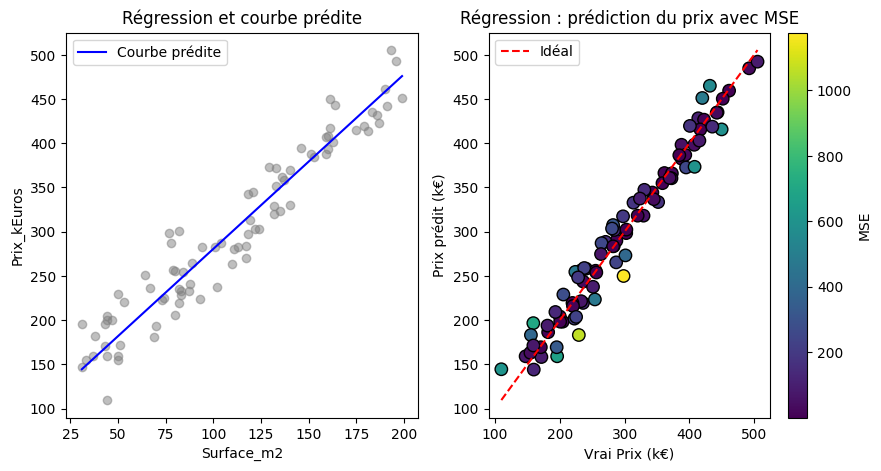

/home/lea/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


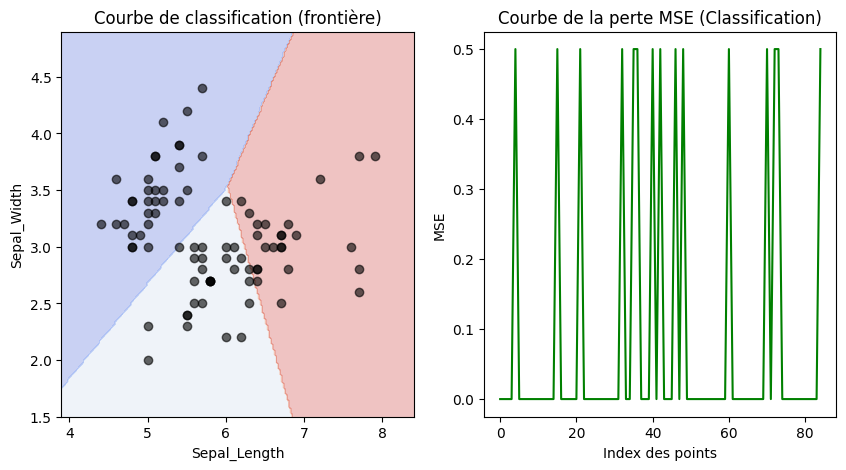

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder

# =========================
# Données
# =========================
df_reg = pd.read_csv('dataset_regression.csv') 
df_clf = pd.read_csv('dataset_classification.csv') 

# =========================
# (1) REGRESSION
# =========================
X_reg = df_reg[["Surface_m2", "Chambres"]]
y_reg = df_reg["Prix_kEuros"]

# Modèle linéaire
reg_model = LinearRegression().fit(X_reg, y_reg)
y_pred_reg = reg_model.predict(X_reg)

# Perte MSE
def mse_loss(y_true, y_pred):
    return 0.5 * (y_true - y_pred)**2

mse_reg = [mse_loss(y_reg.iloc[i], y_pred_reg[i]) for i in range(len(y_reg))]

# Courbe prédite (Surface_m2 variable, Chambres fixé à la moyenne)
x_vals = np.linspace(X_reg["Surface_m2"].min(), X_reg["Surface_m2"].max(), 100).reshape(-1,1)
X_curve = np.hstack([x_vals, np.full_like(x_vals, X_reg["Chambres"].mean())])
y_curve = reg_model.predict(X_curve)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(x_vals, y_curve, color="blue", label="Courbe prédite")
plt.scatter(X_reg["Surface_m2"], y_reg, alpha=0.5, color="gray")
plt.xlabel("Surface_m2")
plt.ylabel("Prix_kEuros")
plt.title("Régression et courbe prédite")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_reg, y_pred_reg, c=mse_reg, cmap='viridis', s=80, edgecolors='k')
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--', label="Idéal")
plt.xlabel("Vrai Prix (k€)")
plt.ylabel("Prix prédit (k€)")
plt.title("Régression : prédiction du prix avec MSE")
cbar = plt.colorbar()
cbar.set_label("MSE")
plt.legend()
plt.show()

# =========================
# (2) CLASSIFICATION
# =========================
X_clf = df_clf[["Sepal_Length", "Sepal_Width"]]
y_clf = LabelEncoder().fit_transform(df_clf["Classe"])

clf_model = LogisticRegression(max_iter=1000).fit(X_clf, y_clf)
y_pred_clf = clf_model.predict(X_clf)

# MSE pour classification (erreur = label réel - prédiction numérique)
mse_clf = 0.5 * (y_clf - y_pred_clf)**2

# Courbe de séparation
x_min, x_max = X_clf["Sepal_Length"].min()-0.5, X_clf["Sepal_Length"].max()+0.5
y_min, y_max = X_clf["Sepal_Width"].min()-0.5, X_clf["Sepal_Width"].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = clf_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.plot(X_clf["Sepal_Length"], X_clf["Sepal_Width"], "ko", alpha=0.6)
plt.xlabel("Sepal_Length")
plt.ylabel("Sepal_Width")
plt.title("Courbe de classification (frontière)")

plt.subplot(1,2,2)
plt.plot(range(len(y_clf)), mse_clf, "g-")
plt.xlabel("Index des points")
plt.ylabel("MSE")
plt.title("Courbe de la perte MSE (Classification)")
plt.show()



#### b - Equation de la tangente

In [5]:
import pandas as pd
import sympy as sp
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

df_reg = pd.read_csv('dataset_regression.csv')  # colonnes Surface_m2,Chambres,Prix_kEuros
df_clf = pd.read_csv('dataset_classification.csv') # Sepal_Length,Sepal_Width,Classe

# =========================
# (1) REGRESSION
# =========================
X_reg = df_reg[["Surface_m2", "Chambres"]]
y_reg = df_reg["Prix_kEuros"]

model_reg = LinearRegression().fit(X_reg, y_reg)

# Equation du plan de régression
coef_surface, coef_chambres = model_reg.coef_
intercept = model_reg.intercept_
print("Équation du plan de régression :")
print(f"Prix = {intercept:.2f} + {coef_surface:.2f}*Surface + {coef_chambres:.2f}*Chambres")

import numpy as np
y_pred_reg = model_reg.predict(X_reg)
mse_reg = 0.5 * (y_reg - y_pred_reg)**2

# Gradient de la MSE par rapport aux prédictions
x, y = sp.symbols("x y")
L_mse = 0.5 * (y - x)**2
grad_mse = [sp.diff(L_mse, var) for var in (x, y)]
print("Gradient MSE :", grad_mse)

# =========================
# (2) CLASSIFICATION
# =========================
# On suppose que les points de "Setosa" sont approximés par une ellipse
setosa = df_clf[df_clf.Classe=="Setosa"]

x0, y0 = setosa["Sepal_Length"].mean(), setosa["Sepal_Width"].mean()
a, b = setosa["Sepal_Length"].std(), setosa["Sepal_Width"].std()

x, y = sp.symbols("x y")

# Équation ellipse centrée sur la moyenne
F = ((x - x0)**2)/(a**2) + ((y - y0)**2)/(b**2) - 1

# Choisir un point de Setosa pour la tangente
xP, yP = setosa.iloc[0][["Sepal_Length","Sepal_Width"]]

# Gradient de l'ellipse
Fx, Fy = sp.diff(F, x), sp.diff(F, y)
FxP, FyP = Fx.subs({x:xP,y:yP}), Fy.subs({x:xP,y:yP})

tangent = sp.simplify(FxP*(x-xP) + FyP*(y-yP))
print("Équation de la tangente à l'ellipse (classe Setosa) en un point :")
print(sp.Eq(tangent,0))


Équation du plan de régression :
Prix = 44.20 + 1.97*Surface + 13.44*Chambres
Gradient MSE : [1.0*x - 1.0*y, -1.0*x + 1.0*y]
Équation de la tangente à l'ellipse (classe Setosa) en un point :
Eq(12.5435329642677*x + 4.8952626490493*y - 90.1001359627135, 0)


### II - ENTROPIE CROISÉE BINAIRE

### III - ENTROPIE CROISÉE CATÉGORIELLE



### Introduction

L'**entropie croisée catégorielle** est une fonction de perte fondamentale en apprentissage automatique, utilisée pour les problèmes de **classification multi-classes**. Elle mesure la divergence entre la distribution de probabilité prédite par le modèle et la distribution réelle (représentée par un encodage one-hot).

### Définition Mathématique

Pour un exemple avec **K** classes, la perte est définie par :

$$L = -\sum_{i=0}^{K-1} y_i \log(\hat{y}_i)$$

où :
- $y_i \in \{0, 1\}$ : vecteur one-hot représentant la vraie classe (1 pour la classe correcte, 0 ailleurs)
- $\hat{y}_i \in [0, 1]$ : probabilité prédite pour la classe $i$
- $\sum_{i=0}^{K-1} \hat{y}_i = 1$ : les probabilités prédites forment une distribution

### Interprétation

Puisque $y$ est un vecteur one-hot, un seul terme de la somme est non nul :

$$L = -\log(\hat{y}_{\text{classe vraie}})$$

Cette formulation pénalise logarithmiquement les mauvaises prédictions :
- Si $\hat{y}_{\text{classe vraie}} = 1$ (prédiction parfaite) → $L = 0$
- Si $\hat{y}_{\text{classe vraie}} = 0.5$ → $L \approx 0.69$
- Si $\hat{y}_{\text{classe vraie}} \to 0$ (très mauvaise prédiction) → $L \to +\infty$



## 1) - Expression du gradient

Nous avons fixé le nombre de classes n à 2.

In [5]:
import sympy as sp

# Définir le nombre de classes
n = 2  # Modifiable

# Créer les variables symboliques
y = sp.symbols(f'y0:{n}')  # y0, y1, y2, ...
y_hat = sp.symbols(f'ŷ0:{n}')  # ŷ0, ŷ1, ŷ2, ...

# Fonction de perte entropie croisée catégorielle
L = -sum(y[i] * sp.log(y_hat[i]) for i in range(n))

print("Fonction de perte (entropie croisée catégorielle):")
print("L =", L)

# Calculer le gradient par rapport à chaque ŷ_i
print("\nGradient ∇L:")
for i in range(n):
    grad = sp.diff(L, y_hat[i])
    print(f"∂L/∂ŷ{i} =", sp.simplify(grad))


Fonction de perte (entropie croisée catégorielle):
L = -y0*log(ŷ0) - y1*log(ŷ1)

Gradient ∇L:
∂L/∂ŷ0 = -y0/ŷ0
∂L/∂ŷ1 = -y1/ŷ1


#### 2) - Étude des propriétés de convexité


In [6]:
import sympy as sp
from sympy import symbols, log, diff, simplify, Matrix, hessian



# Cas simplifié : 2 classes pour la démonstration
n = 2

# Variables symboliques
y = sp.symbols(f'y0:{n}', real=True)
y_hat = sp.symbols(f'ŷ0:{n}', positive=True, real=True)

# Fonction de perte
L = -sum(y[i] * log(y_hat[i]) for i in range(n))

print("\n1. FONCTION DE PERTE")

print(f"L = {L}")

# Gradient (dérivées premières)
print("\n2. GRADIENT (Dérivées premières)")

gradients = []
for i in range(n):
    grad = diff(L, y_hat[i])
    gradients.append(grad)
    print(f"∂L/∂ŷ{i} = {simplify(grad)}")

# Matrice Hessienne (dérivées secondes)
print("\n3. MATRICE HESSIENNE (Dérivées secondes)")

y_hat_vec = Matrix(y_hat)
H = hessian(L, y_hat_vec)
print("H =")
sp.pprint(H)

print("\n4. ANALYSE DES ÉLÉMENTS DE LA HESSIENNE")

for i in range(n):
    for j in range(n):
        print(f"∂²L/∂ŷ{i}∂ŷ{j} = {simplify(H[i,j])}")

# Vérification de la positivité des éléments diagonaux
print("\n5. PROPRIÉTÉS DE CONVEXITÉ")

print("Éléments diagonaux de la Hessienne:")
for i in range(n):
    h_ii = H[i,i]
    print(f"  H[{i},{i}] = {h_ii}")
    print(f"  Pour y{i} > 0 et ŷ{i} > 0: H[{i},{i}] > 0")

print("\nÉléments hors diagonale:")
for i in range(n):
    for j in range(i+1, n):
        print(f"  H[{i},{j}] = {H[i,j]} (nul)")

# Cas général avec n classes
print("\n6. GÉNÉRALISATION À K CLASSES")

print("Pour K classes, la matrice Hessienne est:")
print("  • Diagonale: H[i,j] = 0 si i ≠ j")
print("  • H[i,i] = y_i / ŷ_i²")
print("\nConclusion:")
print("  • Si y_i > 0 et ŷ_i > 0 ∀i, alors H[i,i] > 0")
print("  • La Hessienne est diagonale avec éléments positifs")
print("  • La fonction est CONVEXE par rapport à ŷ")




1. FONCTION DE PERTE
L = -y0*log(ŷ0) - y1*log(ŷ1)

2. GRADIENT (Dérivées premières)
∂L/∂ŷ0 = -y0/ŷ0
∂L/∂ŷ1 = -y1/ŷ1

3. MATRICE HESSIENNE (Dérivées secondes)
H =
⎡ y₀     ⎤
⎢───   0 ⎥
⎢  2     ⎥
⎢ŷ₀      ⎥
⎢        ⎥
⎢      y₁⎥
⎢ 0   ───⎥
⎢       2⎥
⎣     ŷ₁ ⎦

4. ANALYSE DES ÉLÉMENTS DE LA HESSIENNE
∂²L/∂ŷ0∂ŷ0 = y0/ŷ0**2
∂²L/∂ŷ0∂ŷ1 = 0
∂²L/∂ŷ1∂ŷ0 = 0
∂²L/∂ŷ1∂ŷ1 = y1/ŷ1**2

5. PROPRIÉTÉS DE CONVEXITÉ
Éléments diagonaux de la Hessienne:
  H[0,0] = y0/ŷ0**2
  Pour y0 > 0 et ŷ0 > 0: H[0,0] > 0
  H[1,1] = y1/ŷ1**2
  Pour y1 > 0 et ŷ1 > 0: H[1,1] > 0

Éléments hors diagonale:
  H[0,1] = 0 (nul)

6. GÉNÉRALISATION À K CLASSES
Pour K classes, la matrice Hessienne est:
  • Diagonale: H[i,j] = 0 si i ≠ j
  • H[i,i] = y_i / ŷ_i²

Conclusion:
  • Si y_i > 0 et ŷ_i > 0 ∀i, alors H[i,i] > 0
  • La Hessienne est diagonale avec éléments positifs
  • La fonction est CONVEXE par rapport à ŷ


## Propriétés de Convexité

### Matrice Hessienne

La matrice Hessienne de la fonction de perte par rapport aux prédictions $\hat{y}$ est :

$$H_{ij} = \frac{\partial^2 L}{\partial \hat{y}_i \partial \hat{y}_j}$$

Pour l'entropie croisée catégorielle, la Hessienne possède une structure particulière :

- **Éléments diagonaux** : $H_{ii} = \frac{y_i}{\hat{y}_i^2}$
- **Éléments hors diagonale** : $H_{ij} = 0$ pour $i \neq j$

### Convexité

La fonction de perte est **strictement convexe** par rapport aux prédictions $\hat{y}$ car :

1. La Hessienne est **diagonale** (pas d'interaction entre les composantes)
2. Les éléments diagonaux sont **strictement positifs** : 
$H_{ii} = \frac{y_i}{\hat{y}_i^2} > 0$ lorsque $y_i > 0$ et $\hat{y}_i > 0$

3. Une matrice diagonale à éléments positifs est **définie positive**

### Implications Pratiques

- **Optimisation garantie** : La convexité assure qu'il n'existe pas de minimum local (tout minimum est global)
- **Convergence stable** : Les algorithmes d'optimisation par gradient convergeront vers l'optimum
- **Unicité de la solution** : Pour un ensemble de données donné, il existe une unique solution optimale
- **Pas de piège** : Contrairement aux fonctions non-convexes, il n'y a pas de risque de rester bloqué dans un minimum local sous-optimal

Cette propriété de convexité est l'une des raisons pour lesquelles l'entropie croisée catégorielle est la fonction de perte standard en classification multi-classes.

#### 3) - a - Représentation les courbes de ses fonctions

Nous avons implémenté sur le jeu de données de la régréssion, la régression linéaire et, sur le jeu de données de la classification, la régression logistique.


/home/lethycia/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


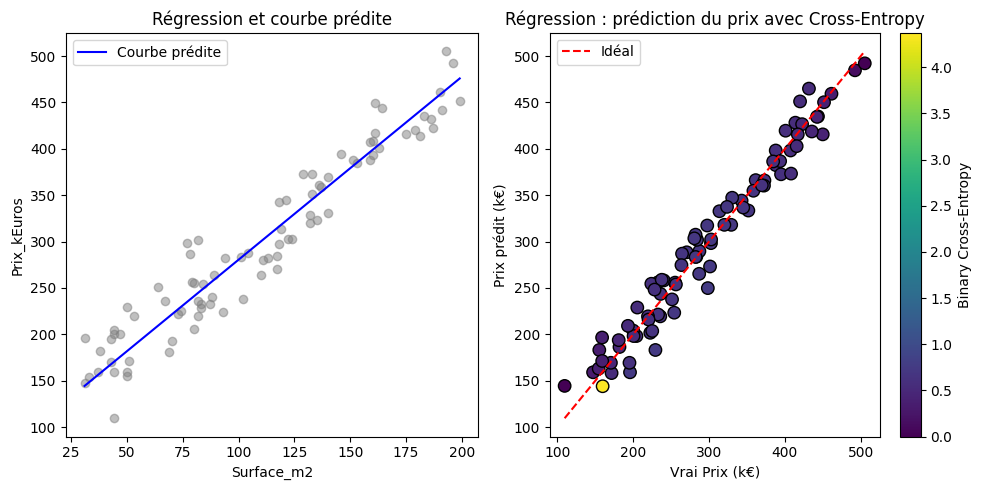

/home/lethycia/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/lethycia/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


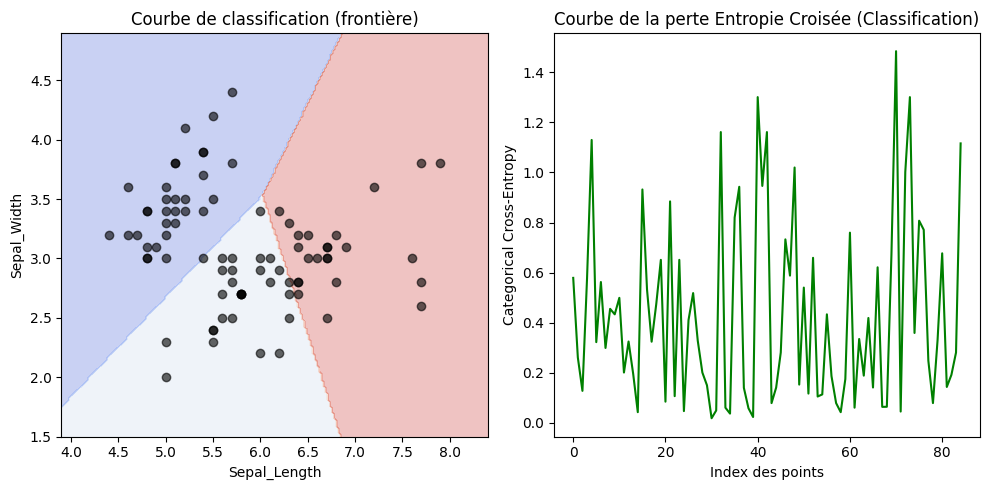

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder

# =========================
# Données
# =========================
df_reg = pd.read_csv('dataset_regression.csv') 
df_clf = pd.read_csv('dataset_classification.csv') 

# =========================
# (1) REGRESSION avec Entropie Croisée Binaire
# =========================
X_reg = df_reg[["Surface_m2", "Chambres"]]
y_reg = df_reg["Prix_kEuros"]

# Modèle linéaire
reg_model = LinearRegression().fit(X_reg, y_reg)
y_pred_reg = reg_model.predict(X_reg)

# Pour la régression, on peut utiliser l'entropie croisée binaire
# en normalisant les valeurs entre 0 et 1
def normalize_to_prob(y):
    """Normalise les valeurs entre 0 et 1"""
    return (y - y.min()) / (y.max() - y.min() + 1e-10)

y_reg_norm = normalize_to_prob(y_reg)
y_pred_reg_norm = normalize_to_prob(y_pred_reg)

# Entropie croisée binaire pour régression
def binary_crossentropy(y_true, y_pred):
    """L = -[y*log(ŷ) + (1-y)*log(1-ŷ)]"""
    eps = 1e-15
    y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
    return -(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))

ce_reg = [binary_crossentropy(y_reg_norm.iloc[i], y_pred_reg_norm[i]) for i in range(len(y_reg))]

# Courbe prédite (Surface_m2 variable, Chambres fixé à la moyenne)
x_vals = np.linspace(X_reg["Surface_m2"].min(), X_reg["Surface_m2"].max(), 100).reshape(-1,1)
X_curve = np.hstack([x_vals, np.full_like(x_vals, X_reg["Chambres"].mean())])
y_curve = reg_model.predict(X_curve)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(x_vals, y_curve, color="blue", label="Courbe prédite")
plt.scatter(X_reg["Surface_m2"], y_reg, alpha=0.5, color="gray")
plt.xlabel("Surface_m2")
plt.ylabel("Prix_kEuros")
plt.title("Régression et courbe prédite")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_reg, y_pred_reg, c=ce_reg, cmap='viridis', s=80, edgecolors='k')
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--', label="Idéal")
plt.xlabel("Vrai Prix (k€)")
plt.ylabel("Prix prédit (k€)")
plt.title("Régression : prédiction du prix avec Cross-Entropy")
cbar = plt.colorbar()
cbar.set_label("Binary Cross-Entropy")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# (2) CLASSIFICATION avec Entropie Croisée Catégorielle
# =========================
X_clf = df_clf[["Sepal_Length", "Sepal_Width"]]
y_clf = LabelEncoder().fit_transform(df_clf["Classe"])

clf_model = LogisticRegression(max_iter=1000, multi_class='multinomial').fit(X_clf, y_clf)
y_pred_clf = clf_model.predict(X_clf)

# Probabilités prédites pour chaque classe
y_pred_proba = clf_model.predict_proba(X_clf)

# Entropie croisée catégorielle pour chaque point
def categorical_crossentropy(y_true_index, y_pred_proba):
    """L = -log(ŷ_classe_vraie)"""
    n = len(y_true_index)
    losses = np.zeros(n)
    for i in range(n):
        true_class = y_true_index[i]
        losses[i] = -np.log(y_pred_proba[i, true_class] + 1e-15)
    return losses

ce_clf = categorical_crossentropy(y_clf, y_pred_proba)

# Courbe de séparation
x_min, x_max = X_clf["Sepal_Length"].min()-0.5, X_clf["Sepal_Length"].max()+0.5
y_min, y_max = X_clf["Sepal_Width"].min()-0.5, X_clf["Sepal_Width"].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = clf_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.plot(X_clf["Sepal_Length"], X_clf["Sepal_Width"], "ko", alpha=0.6)
plt.xlabel("Sepal_Length")
plt.ylabel("Sepal_Width")
plt.title("Courbe de classification (frontière)")

plt.subplot(1,2,2)
plt.plot(range(len(y_clf)), ce_clf, "g-")
plt.xlabel("Index des points")
plt.ylabel("Categorical Cross-Entropy")
plt.title("Courbe de la perte Entropie Croisée (Classification)")
plt.tight_layout()
plt.show()

#### b - Equation de la tangente

In [11]:
import sympy as sp
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# =========================
# Chargement des données
# =========================
df_clf = pd.read_csv('dataset_classification.csv')
X_clf = df_clf[["Sepal_Length", "Sepal_Width"]].values
y_clf = LabelEncoder().fit_transform(df_clf["Classe"])

# Entraîner le modèle
clf_model = LogisticRegression(max_iter=1000, multi_class='multinomial').fit(X_clf, y_clf)


# =========================
# 1. ÉQUATION DE RÉGRESSION (LOGISTIQUE)
# =========================
print("\n1. ÉQUATION DE RÉGRESSION LOGISTIQUE")
print("-"*80)

# Variables symboliques
x1, x2 = sp.symbols('x1 x2', real=True)
w0, w1, w2, b = sp.symbols('w0 w1 w2 b', real=True)

# Logit (score avant softmax)
z = w0 + w1*x1 + w2*x2

print("Logit (score) pour une classe k:")
print(f"z_k = w0 + w1*x1 + w2*x2")
sp.pprint(z)

# Softmax (probabilité)
print("\nProbabilité après softmax:")
print("ŷ_k = exp(z_k) / Σ_j exp(z_j)")

# Coefficients réels du modèle pour la classe 0
coef = clf_model.coef_[0]
intercept = clf_model.intercept_[0]

print(f"\nPour la classe 0 avec les valeurs entraînées:")
z_numeric = intercept + coef[0]*x1 + coef[1]*x2
print(f"z_0 = {intercept:.4f} + {coef[0]:.4f}*x1 + {coef[1]:.4f}*x2")
sp.pprint(z_numeric)

# =========================
# 2. GRADIENT D'ENTROPIE CROISÉE CATÉGORIELLE
# =========================
print("\n\n2. GRADIENT D'ENTROPIE CROISÉE CATÉGORIELLE")
print("-"*80)

# Variables pour le gradient
n_classes = len(np.unique(y_clf))
y = sp.symbols(f'y0:{n_classes}')
y_hat = sp.symbols(f'ŷ0:{n_classes}', positive=True)

# Fonction de perte
L = -sum(y[i] * sp.log(y_hat[i]) for i in range(n_classes))

print("Fonction de perte:")
print("L = -Σ(y_i * log(ŷ_i))")
sp.pprint(L)

print("\nGradient ∇L par rapport aux prédictions:")
for i in range(n_classes):
    grad = sp.diff(L, y_hat[i])
    print(f"∂L/∂ŷ{i} = {sp.simplify(grad)}")

print("\nGradient par rapport aux logits (avec softmax):")
print("∂L/∂z_i = ŷ_i - y_i")

# =========================
# 3. ÉQUATION DE LA TANGENTE EN UN POINT
# =========================
print("\n\n3. ÉQUATION DE LA TANGENTE")
print("-"*80)

# Choisir un point (le premier point du dataset)
point_idx = 0
x1_val = X_clf[point_idx, 0]
x2_val = X_clf[point_idx, 1]

# Calculer la probabilité au point
y_pred_proba = clf_model.predict_proba(X_clf[point_idx:point_idx+1])[0]
y_true_class = y_clf[point_idx]

# Fonction symbolique de perte pour une classe (en fonction de ŷ)
y_hat_sym = sp.symbols('ŷ', positive=True)
y_true_val = 1  # Pour la vraie classe
L_point = -y_true_val * sp.log(y_hat_sym)

# Gradient (dérivée)
dL_dyhat = sp.diff(L_point, y_hat_sym)

print(f"Point choisi: x1={x1_val:.4f}, x2={x2_val:.4f}")
print(f"Vraie classe: {y_true_class}")
print(f"Probabilité prédite pour la vraie classe: ŷ = {y_pred_proba[y_true_class]:.4f}")

print("\nFonction de perte en ce point:")
print("L(ŷ) = -log(ŷ)")
sp.pprint(L_point)

print("\nDérivée de la perte:")
print("dL/dŷ = ")
sp.pprint(dL_dyhat)

# Valeur de la dérivée au point
slope = float(dL_dyhat.subs(y_hat_sym, y_pred_proba[y_true_class]))
y_val = float(L_point.subs(y_hat_sym, y_pred_proba[y_true_class]))

print(f"\nAu point ŷ = {y_pred_proba[y_true_class]:.4f}:")
print(f"  Perte L = {y_val:.4f}")
print(f"  Pente dL/dŷ = {slope:.4f}")

# Équation de la tangente: y = f(a) + f'(a)(x - a)
tangent = y_val + slope * (y_hat_sym - y_pred_proba[y_true_class])

print("\nÉquation de la tangente:")
print(f"T(ŷ) = L(ŷ₀) + (dL/dŷ)|ŷ₀ * (ŷ - ŷ₀)")
print(f"T(ŷ) = {y_val:.4f} + {slope:.4f} * (ŷ - {y_pred_proba[y_true_class]:.4f})")
sp.pprint(sp.simplify(tangent))

# Forme développée
tangent_expanded = sp.expand(tangent)
print("\nForme développée:")
sp.pprint(tangent_expanded)


print("RÉSUMÉ")

print(f"• Équation de régression: prix = {intercept:.4f} + {coef[0]:.4f}*surface + {coef[1]:.4f}*chambres")
print(f"• Gradient général: ∂L/∂ŷ_i = -y_i/ŷ_i")
print(f"• Tangente au point ŷ={y_pred_proba[y_true_class]:.4f}: T(ŷ) = {y_val:.4f} + {slope:.4f}*(ŷ - {y_pred_proba[y_true_class]:.4f})")


/home/lethycia/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



1. ÉQUATION DE RÉGRESSION LOGISTIQUE
--------------------------------------------------------------------------------
Logit (score) pour une classe k:
z_k = w0 + w1*x1 + w2*x2
w₀ + w₁⋅x₁ + w₂⋅x₂

Probabilité après softmax:
ŷ_k = exp(z_k) / Σ_j exp(z_j)

Pour la classe 0 avec les valeurs entraînées:
z_0 = 7.1361 + -2.3339*x1 + 1.9591*x2
-2.33389491023554⋅x₁ + 1.95910923062443⋅x₂ + 7.13609499926936


2. GRADIENT D'ENTROPIE CROISÉE CATÉGORIELLE
--------------------------------------------------------------------------------
Fonction de perte:
L = -Σ(y_i * log(ŷ_i))
-y₀⋅log(ŷ₀) - y₁⋅log(ŷ₁) - y₂⋅log(ŷ₂)

Gradient ∇L par rapport aux prédictions:
∂L/∂ŷ0 = -y0/ŷ0
∂L/∂ŷ1 = -y1/ŷ1
∂L/∂ŷ2 = -y2/ŷ2

Gradient par rapport aux logits (avec softmax):
∂L/∂z_i = ŷ_i - y_i


3. ÉQUATION DE LA TANGENTE
--------------------------------------------------------------------------------
Point choisi: x1=6.1000, x2=2.8000
Vraie classe: 1
Probabilité prédite pour la vraie classe: ŷ = 0.5605

Fonction de perte 

### IV - PERTE DE HUBER

La **perte de Huber** ou **erreur absolue moyenne lisse** est une fonction de perte qui reprend les caractéristiques avantageuses des fonctions de perte **erreur absolue moyenne** et **erreur quadratique moyenne** et les combine en une seule fonction de perte. La nature hybride de la perte de Huber la rend moins sensible aux valeurs aberrantes, tout comme la MAE, mais pénalise également les erreurs mineures au sein de l'échantillon de données, tout comme la MSE. La fonction de perte de Huber est également utilisée dans les tâches d'apprentissage automatique de la régression.

L'équation mathématique de la perte de Huber est la suivante :

L(δ, y, f(x))  = (1/2) * (f(x) - y)^2    si |f(x) - y| <= δ

        ou

L(δ, y, f(x))  = δ * |f(x) - y| - (1/2) * δ^2   si |f(x) - y| > δ

Où L représente la fonction de perte de Huber; δ est le paramètre delta, qui détermine le seuil de commutation entre les composantes quadratique et linéaire de la fonction de perte; y est la valeur réelle ou la valeur cible; f(x) est la valeur prédite.

#### 1) - Expression du gradient

In [8]:
import sympy as sp

# Définition des variables
x, y, delta = sp.symbols("x y delta", real=True)
r = y - x

#  Cas 1 : |r| <= delta 
L_small = 0.5 * r**2
grad_small = [sp.diff(L_small, var) for var in (x, y)]
print("Gradient cas |y-x| <= delta :", grad_small)

#  Cas 2 : |r| > delta 
L_large = delta * (sp.Abs(r)) - 0.5*(delta**2)
grad_large = [sp.diff(L_large, var) for var in (x, y)]
print("Gradient cas |y-x| > delta :", grad_large)


Gradient cas |y-x| <= delta : [1.0*x - 1.0*y, -1.0*x + 1.0*y]
Gradient cas |y-x| > delta : [delta*sign(x - y), -delta*sign(x - y)]


              ⎧ (x−y,y−x)                       ​si ∣y−x∣≤δ
   ∇L(x,y)  = ⎨  
              ⎩(δ(y−x)/∣x−y|,δ(y−x)/|y−x|)      ​si ∣y−x∣>δ                 

#### 2) - Étude des propriétés de convexité

In [9]:

# --- Cas |y-x| <= delta : Fonction Quadratique ---
L_small = 0.5 * r**2

# Gradient
grad = [sp.diff(L_small, var) for var in (x, y)]
print("Gradient :", grad)

# Hessienne
hessian = sp.hessian(L_small, (x, y))
print("Hessienne :")
sp.pprint(hessian)

# Points critiques : résoudre ∇L = 0
critical_points = sp.solve(grad, (x, y))
print("Points critiques :", critical_points)

# Valeurs propres de la Hessienne
eigvals = hessian.eigenvals()
print("Valeurs propres :", eigvals)


Gradient : [1.0*x - 1.0*y, -1.0*x + 1.0*y]
Hessienne :
⎡1.0   -1.0⎤
⎢          ⎥
⎣-1.0  1.0 ⎦
Points critiques : {x: y}
Valeurs propres : {0: 1, 2.00000000000000: 1}



##### Interprétation :

- Quand x<y, la dérivée par rapport à x est négative → la fonction diminue si on augmente x (ce qui pousse x vers y).
- Quand x>y, la dérivée par rapport à x est positive → la fonction diminue si on diminue x.

**Le gradient indique donc la direction de descente vers le minimum**.


Etant donné que la Hessienne montre la courbure de la fonction. Et que les valeurs propres sont : 0 et 2. Nous avons :
- 2>0 → direction de courbure positive (convexité)
- 0 → direction plate (la fonction est constante le long de x=y)
  
Ainsi,
- La fonction est convexe par rapport à x et y.
- Le minimum global se situe le long de la diagonale x=y.
- La valeur propre nulle correspond à la direction où la fonction ne change pas, la ligne x=y.

**La Hessienne est semi-définie positive et donc, pour |y-x| <= delta la fonction de perte est convexe.**

In [14]:

# --- Cas |y-x| > delta : linéaire ---
L_large = delta * (sp.Abs(r) - 0.5*delta)

# Gradient
grad_large = [sp.diff(L_large, var) for var in (x, y)]
print("Gradient :", grad_large)

# Hessienne
hessian_large = sp.hessian(L_large, (x, y))
print("Hessienne :")
sp.pprint(hessian_large)

# Valeurs propres de la Hessienne
eigvals = hessian_large.eigenvals()
print("Valeurs propres :", eigvals)

Gradient : [delta*sign(x - y), -delta*sign(x - y)]
Hessienne :
⎡2⋅δ⋅δ(x - y)   -2⋅δ⋅δ(x - y)⎤
⎢                            ⎥
⎣-2⋅δ⋅δ(x - y)  2⋅δ⋅δ(x - y) ⎦
Valeurs propres : {4*delta*DiracDelta(x - y): 1, 0: 1}


##### Interprétation :

- Le gradient est borné par δ, contrairement au cas quadratique.

- Il indique la direction pour réduire la perte tel que si x<y (resp. x>y) → la dérivée par rapport à x est négative (resp. positive) → il faut augmenter (resp. réduire) x pour réduire la perte.

Le gradient ne dépend que du signe de l’erreur, pas de son amplitude, ce qui limite l’effet des grandes erreurs (outliers) et fait en sorte qu'il n'y ait aucun point critique.

Comme en pratique, pour toutes les valeurs réelles avec x ≠ y, la Héssienne est nulle, donc la fonction est linéaire et convexe. Alors, il n’y a pas de point critique dans cette zone, car la pente ne s’annule jamais sauf au point de jonction ∣y−x∣=δ.

La perte de Huber combine donc **quadratique** pour petites erreurs (convexe et strictement croissante vers le minimum) et **linéaire** pour grandes erreurs (pente bornée, réduit l’influence des outliers).

#### 3) - a - Représentation les courbes de ses fonctions

/home/lea/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


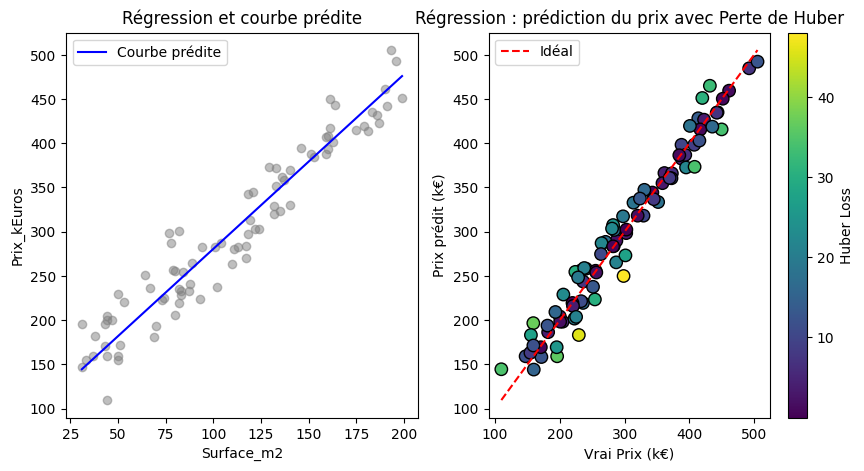

/home/lea/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


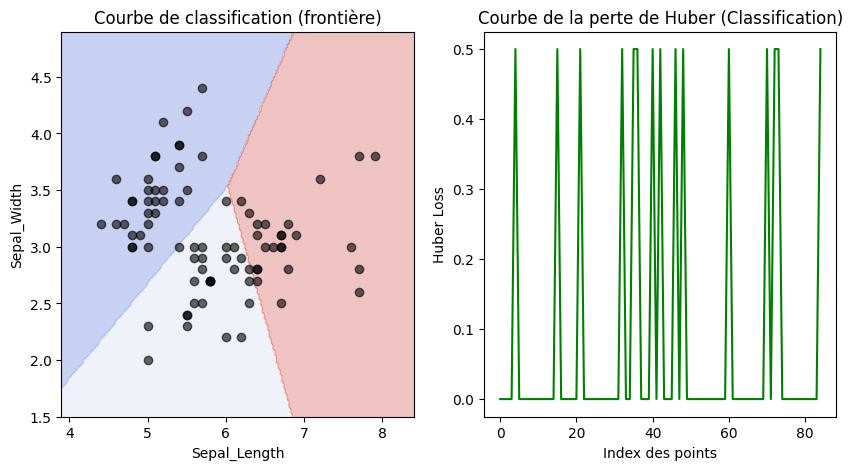

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

# =========================
# Données
# =========================
df_reg = pd.read_csv('dataset_regression.csv')  # colonnes x1,x2,y
df_clf = pd.read_csv('dataset_classification.csv') # Sepal_Length,Sepal_Width,Classe

# =========================
# (1) REGRESSION
# =========================
X_reg = df_reg[["Surface_m2", "Chambres"]]
y_reg = df_reg["Prix_kEuros"]

# Modèle linéaire
reg_model = LinearRegression().fit(X_reg, y_reg)
y_pred = reg_model.predict(X_reg)

# Perte de Huber
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    cond = np.abs(error) <= delta
    return np.where(cond, 0.5 * error**2, delta*(np.abs(error) - 0.5*delta))

huber_reg = huber_loss(y_reg, y_pred)

# Courbe prédite (en fonction de Surface uniquement, Chambres fixé à la moyenne)
x_vals = np.linspace(X_reg["Surface_m2"].min(), X_reg["Surface_m2"].max(), 100).reshape(-1,1)
X_curve = np.hstack([x_vals, np.full_like(x_vals, X_reg["Chambres"].mean())])
y_curve = reg_model.predict(X_curve)

X_reg = df_reg[['Surface_m2','Chambres']]
y_reg = df_reg['Prix_kEuros']

model_reg = LinearRegression()
model_reg.fit(X_reg, y_reg)
x, y, delta = sp.symbols('x y delta', real=True)
r = y - x
L_huber = sp.Piecewise(
    (0.5*r**2, sp.Abs(r) <= delta),
    (delta*(sp.Abs(r)-0.5*delta), True)
)
L_func = sp.lambdify((x, y, delta), L_huber, 'numpy')
delta_val = 1.0 
 
# Calcul de la perte Huber point par point
loss_reg = [L_func(y_pred_reg[i], y_reg.iloc[i], delta_val) for i in range(len(y_reg))]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(x_vals, y_curve, color="blue", label="Courbe prédite")
plt.scatter(X_reg["Surface_m2"], y_reg, alpha=0.5, color="gray")
plt.xlabel("Surface_m2")
plt.ylabel("Prix_kEuros")
plt.title("Régression et courbe prédite")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_reg, y_pred_reg, c=loss_reg, cmap='viridis', s=80, edgecolors='k')
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--', label="Idéal")
plt.xlabel("Vrai Prix (k€)")
plt.ylabel("Prix prédit (k€)")
plt.title("Régression : prédiction du prix avec Perte de Huber")
cbar = plt.colorbar()
cbar.set_label("Huber Loss")
plt.legend()
plt.show()

# =========================
# (2) CLASSIFICATION
# =========================
X_clf = df_clf[["Sepal_Length", "Sepal_Width"]]
y_clf = LabelEncoder().fit_transform(df_clf["Classe"])

clf_model = LogisticRegression(max_iter=1000).fit(X_clf, y_clf)
y_pred_clf = clf_model.predict(X_clf)

# Huber pour classification (erreur = label réel - prédiction numérique)
huber_clf = huber_loss(y_clf, y_pred_clf, delta=1.0)

# Courbe de séparation
x_min, x_max = X_clf["Sepal_Length"].min()-0.5, X_clf["Sepal_Length"].max()+0.5
y_min, y_max = X_clf["Sepal_Width"].min()-0.5, X_clf["Sepal_Width"].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = clf_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.plot(X_clf["Sepal_Length"], X_clf["Sepal_Width"], "ko", alpha=0.6)
plt.xlabel("Sepal_Length")
plt.ylabel("Sepal_Width")
plt.title("Courbe de classification (frontière)")

plt.subplot(1,2,2)
plt.plot(range(len(y_clf)), huber_clf, "g-")
plt.xlabel("Index des points")
plt.ylabel("Huber Loss")
plt.title("Courbe de la perte de Huber (Classification)")
plt.show()


#### b - Equation de la tangente

- En régression, la tangente correspond simplement au plan de régression lui-même.

- En classification avec Sepal_Length et Sepal_Width → si on approxime la frontière de décision par une ellipse (ex. via une Analyse Discriminante Quadratique, ou par ajustement quadratique), alors on peut calculer la tangente en un point donné.

In [31]:
X_reg = df_reg[["Surface_m2", "Chambres"]]
y_reg = df_reg["Prix_kEuros"]

model_reg = LinearRegression().fit(X_reg, y_reg)

# Equation du plan de régression
coef_surface, coef_chambres = model_reg.coef_
intercept = model_reg.intercept_
print("Équation du plan de régression :")
print(f"Prix = {intercept:.2f} + {coef_surface:.2f}*Surface + {coef_chambres:.2f}*Chambres")


# On suppose que les points de "Setosa" sont approximés par une ellipse
setosa = df_clf[df_clf.Classe=="Setosa"]

# Approximation : ellipse centrée sur la moyenne, demi-axes = std
x0, y0 = setosa["Sepal_Length"].mean(), setosa["Sepal_Width"].mean()
a, b = setosa["Sepal_Length"].std(), setosa["Sepal_Width"].std()

# Variables sympy
x, y = sp.symbols("x y")

# Équation ellipse
F = (x**2)/(a**2) + (y**2)/(b**2) - 1

# Choisir un point de Setosa pour la tangente
xP, yP = setosa.iloc[0][["Sepal_Length","Sepal_Width"]]

# Gradient
Fx, Fy = sp.diff(F, x), sp.diff(F, y)
FxP, FyP = Fx.subs({x:xP,y:yP}), Fy.subs({x:xP,y:yP})

# Tangente : Fx(x0,y0)(x-x0) + Fy(x0,y0)(y-y0) = 0
tangent = sp.simplify(FxP*(x-xP) + FyP*(y-yP))
print("Équation de la tangente à l'ellipse (classe Setosa) en un point :")
print(sp.Eq(tangent,0))

Équation du plan de régression :
Prix = 44.20 + 1.97*Surface + 13.44*Chambres
Équation de la tangente à l'ellipse (classe Setosa) en un point :
Eq(113.827881227982*x + 60.7412181759587*y - 879.63555206814, 0)


##### Remarques :

Les termes **"fonction de perte"** et **"fonction de coût"** sont souvent utilisés de manière interchangeable, mais ils ont tous deux des définitions distinctes.
- La **fonction de perte**, également connue sous le nom de fonction d'erreur, quantifie la qualité d'une prédiction unique de l'algorithme d'apprentissage automatique par rapport à la valeur cible réelle. L'essentiel est qu' une fonction de perte s'applique à un seul exemple d'apprentissage et fait partie du processus d'apprentissage global du modèle qui fournit le signal par lequel l'algorithme d'apprentissage du modèle met à jour les poids et les paramètres.
- La **fonction de coût**, parfois appelée fonction objective, est une moyenne de la fonction de perte d'un ensemble de formation contenant plusieurs exemples de formation. La fonction de coût quantifie les performances du modèle sur l'ensemble des données d'apprentissage.